In [1]:
import pandas as pd

df = pd.read_csv('/content/spam.csv', encoding='latin-1')

print(df.head())
print(df.columns)

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  
Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
df = pd.read_csv('/content/spam.csv', encoding='latin-1')

In [4]:
df = df[['v1', 'v2']]

df.columns = ['label', 'text']

df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
print("Shape:", df.shape)

print("\nClass Distribution:")
print(df['label'].value_counts())

Shape: (5572, 2)

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [6]:
print(df.isnull().sum())

label    0
text     0
dtype: int64


In [7]:
df['label'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 4457
Testing Samples: 1115


In [9]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train).toarray()

X_test_tfidf = tfidf.transform(X_test).toarray()

In [10]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(4457, 5000)
(1115, 5000)


In [11]:
model = Sequential()

model.add(Dense(
    128,
    activation='relu',
    input_shape=(5000,)
))

model.add(Dropout(0.3))

model.add(Dense(
    64,
    activation='relu'
))

model.add(Dropout(0.3))

model.add(Dense(
    1,
    activation='sigmoid'
))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,449 (2.47 MB)

 Trainable params: 648,449 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [15]:
history = model.fit(
    X_train_tfidf,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8648 - loss: 0.3326 - val_accuracy: 0.9271 - val_loss: 0.1621
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9815 - loss: 0.0797 - val_accuracy: 0.9742 - val_loss: 0.0724
Epoch 3/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9961 - loss: 0.0170 - val_accuracy: 0.9765 - val_loss: 0.0685
Epoch 4/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9989 - loss: 0.0066 - val_accuracy: 0.9753 - val_loss: 0.0740
Epoch 5/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9989 - loss: 0.0041 - val_accuracy: 0.9787 - val_loss: 0.0862
Epoch 6/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9997 - loss: 0.0024 - val_accuracy: 0.9798 - val_loss: 0.0887


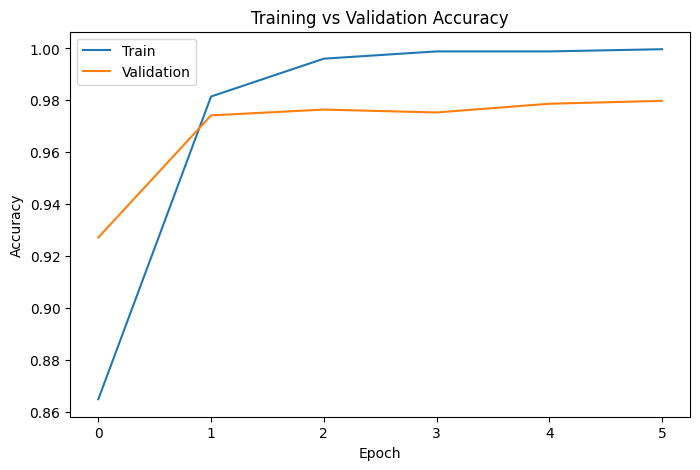

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

plt.show()

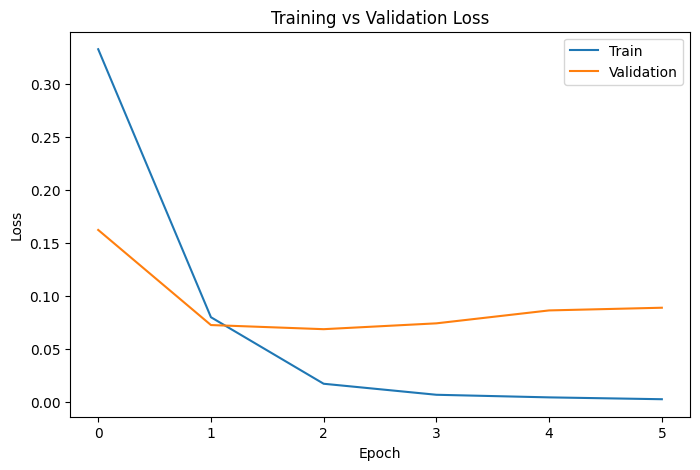

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.show()

In [18]:
loss, accuracy = model.evaluate(
    X_test_tfidf,
    y_test
)

print("Test Accuracy:", accuracy)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9794 - loss: 0.0781
Test Accuracy: 0.9793722033500671


In [19]:
predictions = model.predict(X_test_tfidf)

predictions = (predictions > 0.5).astype(int)

print(classification_report(
    y_test,
    predictions
))

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       965
           1       0.96      0.89      0.92       150

    accuracy                           0.98      1115
   macro avg       0.97      0.94      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [20]:
sample_messages = [

    "Congratulations! You won 10000 rupees",

    "Meeting tomorrow at 10 AM",

    "Claim your free gift card now",

    "Project submission deadline is today"

]

sample_vector = tfidf.transform(
    sample_messages
).toarray()

results = model.predict(sample_vector)

for msg, pred in zip(sample_messages, results):

    if pred > 0.5:
        print("SPAM:", msg)

    else:
        print("HAM:", msg)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
SPAM: Congratulations! You won 10000 rupees
HAM: Meeting tomorrow at 10 AM
SPAM: Claim your free gift card now
HAM: Project submission deadline is today


In [21]:
model.save("spam_classifier_model.h5")